In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Create a simulated social network dataset
people = ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve', 'Frank', 'Grace']
relationships = [
    ('Alice', 'Bob', 5),       # Alice and Bob are close friends
    ('Alice', 'Charlie', 3),   # Alice and Charlie are friends
    ('Bob', 'Diana', 4),       # Bob and Diana are good friends
    ('Charlie', 'Diana', 2),   # Charlie and Diana know each other
    ('Charlie', 'Eve', 6),     # Charlie and Eve are best friends
    ('Diana', 'Frank', 1),     # Diana and Frank are acquaintances
    ('Eve', 'Frank', 3),       # Eve and Frank are friends
    ('Frank', 'Grace', 2),     # Frank and Grace are friends
    ('Grace', 'Alice', 4),     # Grace and Alice are good friends
    ('Bob', 'Eve', 1),         # Bob and Eve know each other
]

# Create directed and undirected graphs
G_directed = nx.DiGraph()
G_undirected = nx.Graph()

for src, dst, weight in relationships:
    G_directed.add_edge(src, dst, weight=weight)
    G_undirected.add_edge(src, dst, weight=weight)

# Directed Graph Visualization

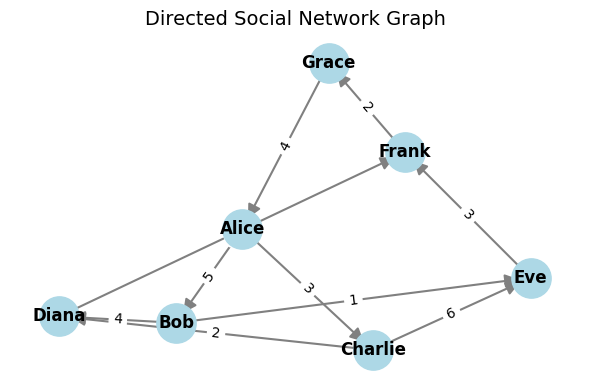

In [3]:
plt.figure(figsize=(6, 4))
pos = nx.spring_layout(G_directed, seed=42)
nx.draw_networkx_nodes(G_directed, pos, node_size=800, node_color='lightblue')
nx.draw_networkx_edges(G_directed, pos, width=1.5, edge_color='gray', 
                      arrows=True, arrowsize=20)
nx.draw_networkx_labels(G_directed, pos, font_size=12, font_weight='bold')
edge_labels = nx.get_edge_attributes(G_directed, 'weight')
nx.draw_networkx_edge_labels(G_directed, pos, edge_labels=edge_labels)

plt.title("Directed Social Network Graph", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig("directed_graph.png", dpi=300)
plt.show()

# Undirected Graph Visualization

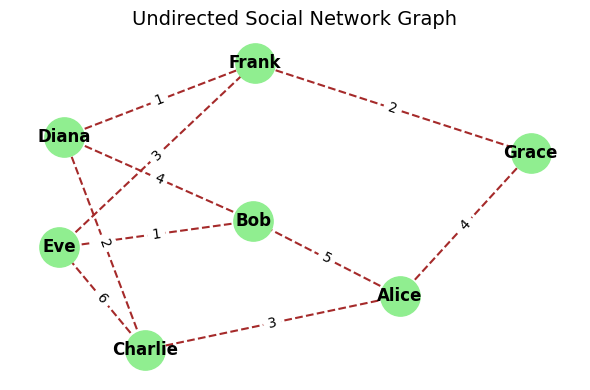

In [5]:
plt.figure(figsize=(6, 4))
pos = nx.spring_layout(G_undirected, seed=42)
nx.draw_networkx_nodes(G_undirected, pos, node_size=800, node_color='lightgreen')
nx.draw_networkx_edges(G_undirected, pos, width=1.5, edge_color='brown', style='dashed')
nx.draw_networkx_labels(G_undirected, pos, font_size=12, font_weight='bold')
edge_labels = nx.get_edge_attributes(G_undirected, 'weight')
nx.draw_networkx_edge_labels(G_undirected, pos, edge_labels=edge_labels)

plt.title("Undirected Social Network Graph", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig("undirected_graph.png", dpi=300)
plt.show()

# Weighted Graph Visualization


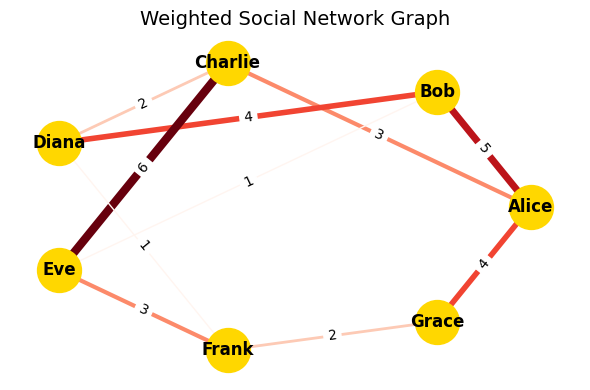

In [7]:
plt.figure(figsize=(6, 4))
pos = nx.circular_layout(G_undirected)

# Normalize weights for edge width and color
weights = [d['weight'] for u, v, d in G_undirected.edges(data=True)]
norm = mcolors.Normalize(vmin=min(weights), vmax=max(weights))
widths = [norm(w)*5 + 1 for w in weights]  # Scale widths
colors = [plt.cm.Reds(norm(w)) for w in weights]  # Red color scale

nx.draw_networkx_nodes(G_undirected, pos, node_size=1000, node_color='gold')
nx.draw_networkx_edges(G_undirected, pos, width=widths, edge_color=colors)
nx.draw_networkx_labels(G_undirected, pos, font_size=12, font_weight='bold')
edge_labels = nx.get_edge_attributes(G_undirected, 'weight')
nx.draw_networkx_edge_labels(G_undirected, pos, edge_labels=edge_labels)

plt.title("Weighted Social Network Graph", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig("weighted_graph.png", dpi=300)
plt.show()

#  Algorithm Implementation: Kruskal's Minimum Spanning Tree (MST) python


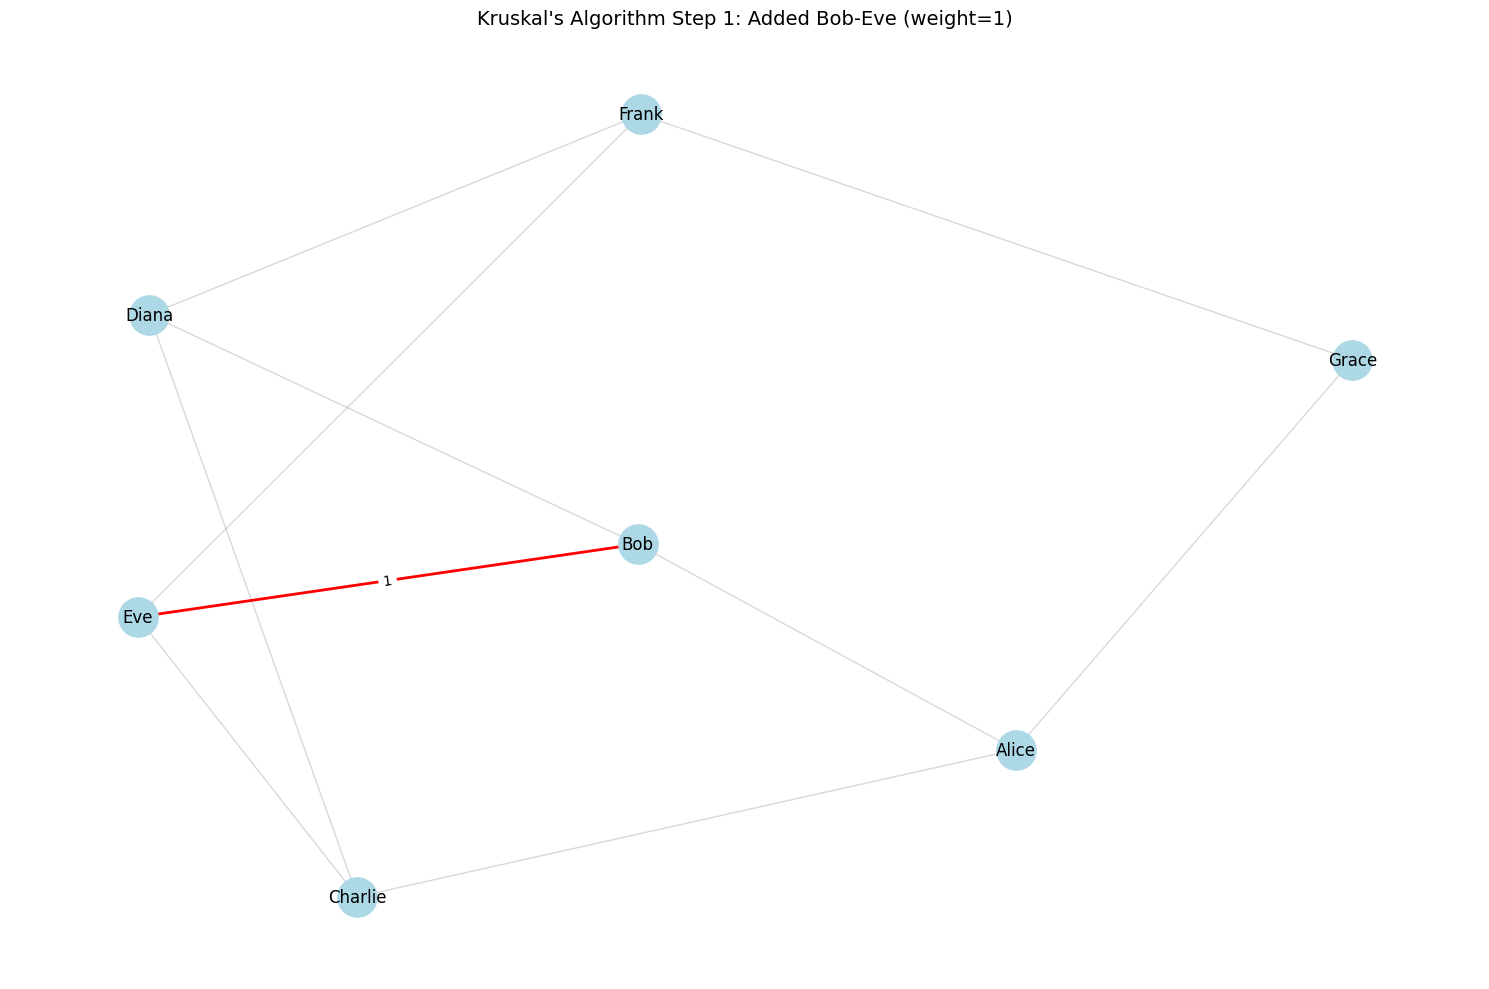

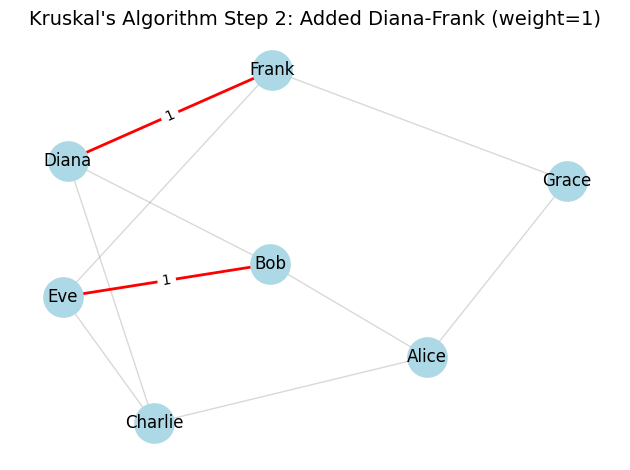

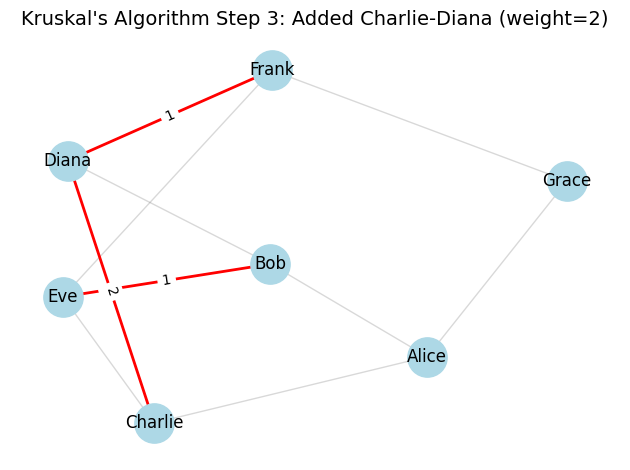

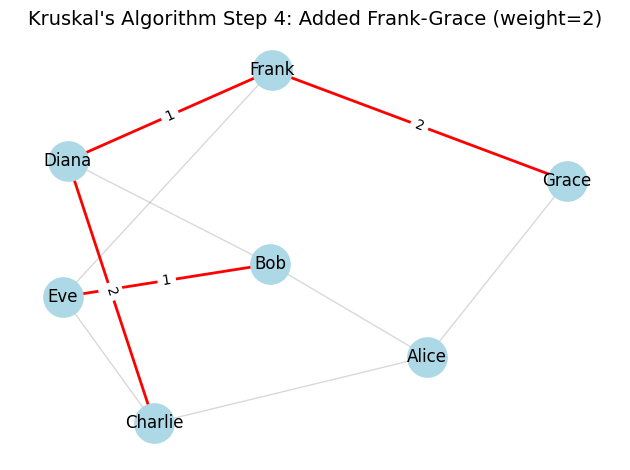

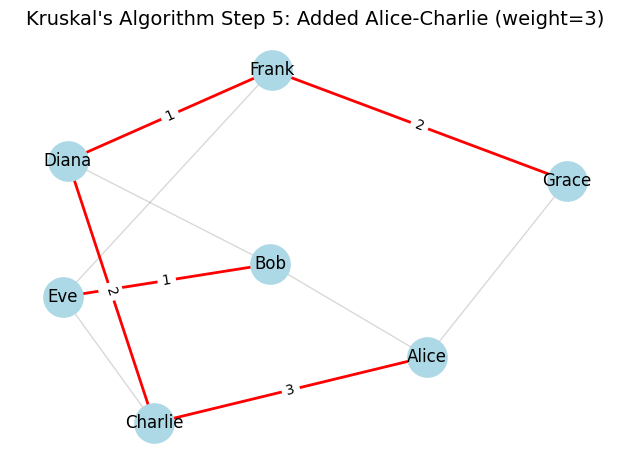

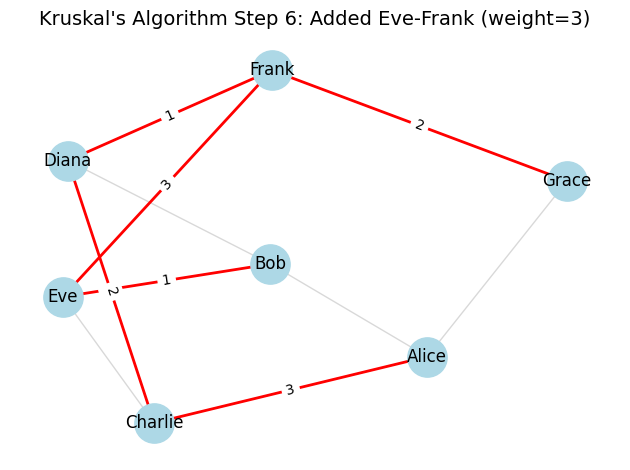

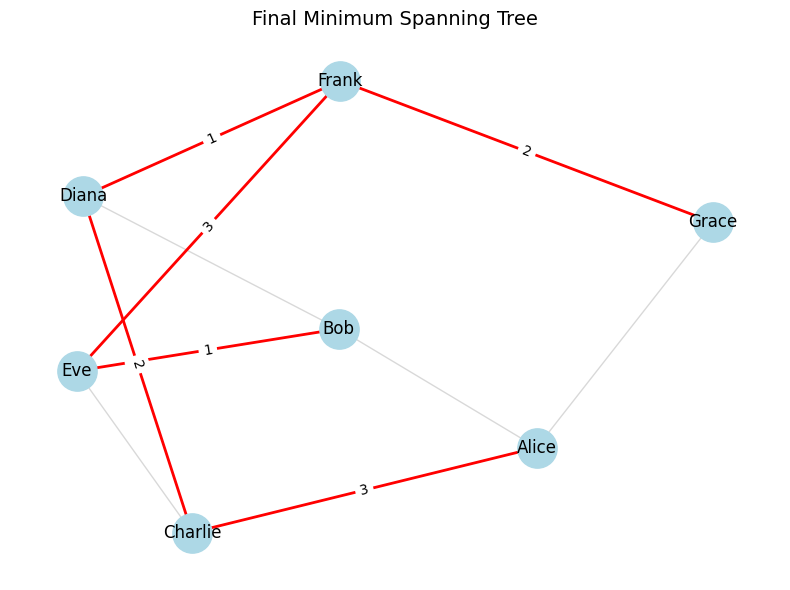

MST edges with weights:
Bob -- Eve: 1
Eve -- Frank: 3
Diana -- Frank: 1
Diana -- Charlie: 2
Frank -- Grace: 2
Charlie -- Alice: 3


In [8]:
# Kruskal's algorithm implementation
def kruskal_visualization(graph):
    mst = nx.Graph()
    edges = sorted(graph.edges(data=True), key=lambda t: t[2].get('weight', 1))
    union_find = {node: node for node in graph.nodes()}
    
    plt.figure(figsize=(15, 10))
    pos = nx.spring_layout(graph, seed=42)
    
    for i, (u, v, d) in enumerate(edges):
        # Find roots
        root_u = union_find[u]
        while union_find[root_u] != root_u:
            root_u = union_find[root_u]
            
        root_v = union_find[v]
        while union_find[root_v] != root_v:
            root_v = union_find[root_v]
            
        if root_u != root_v:
            # Add to MST
            mst.add_edge(u, v, weight=d['weight'])
            union_find[root_v] = root_u
            
            # Visualize this step
            plt.clf()
            nx.draw_networkx_nodes(graph, pos, node_size=800, node_color='lightblue')
            nx.draw_networkx_edges(graph, pos, width=1, edge_color='gray', alpha=0.3)
            nx.draw_networkx_edges(mst, pos, width=2, edge_color='red')
            nx.draw_networkx_labels(graph, pos, font_size=12)
            edge_labels = nx.get_edge_attributes(mst, 'weight')
            nx.draw_networkx_edge_labels(mst, pos, edge_labels=edge_labels)
            
            plt.title(f"Kruskal's Algorithm Step {i+1}: Added {u}-{v} (weight={d['weight']})", fontsize=14)
            plt.axis('off')
            plt.tight_layout()
            plt.pause(1)
    
    return mst

# Run the visualization
mst = kruskal_visualization(G_undirected)

# Final MST visualization
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_undirected, seed=42)
nx.draw_networkx_nodes(G_undirected, pos, node_size=800, node_color='lightblue')
nx.draw_networkx_edges(G_undirected, pos, width=1, edge_color='gray', alpha=0.3)
nx.draw_networkx_edges(mst, pos, width=2, edge_color='red')
nx.draw_networkx_labels(G_undirected, pos, font_size=12)
edge_labels = nx.get_edge_attributes(mst, 'weight')
nx.draw_networkx_edge_labels(mst, pos, edge_labels=edge_labels)

plt.title("Final Minimum Spanning Tree", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig("mst_final.png", dpi=300)
plt.show()

print("MST edges with weights:")
for u, v, d in mst.edges(data=True):
    print(f"{u} -- {v}: {d['weight']}")